In [1]:
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
import scipy.signal as signal
import random
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath("../astro_tool"))
print(sys.path)
import astro_tool.scripts.base as base


2026-07-21 14:25:44.427 | INFO     | astro_tool.config:<module>:17 - PROJ_ROOT path is: /Users/amon/Documents/Apps/Python/astro_tool


['/Users/amon/Documents/Apps/Python/astro_tool/notebooks', '/opt/anaconda3/envs/astro_tool/lib/python312.zip', '/opt/anaconda3/envs/astro_tool/lib/python3.12', '/opt/anaconda3/envs/astro_tool/lib/python3.12/lib-dynload', '', '/opt/anaconda3/envs/astro_tool/lib/python3.12/site-packages', '/Users/amon/Documents/Apps/Python/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool']
2026-07-21 14:25:44.439 | INFO     | config:<module>:17 - PROJ_ROOT path is: /Users/amon/Documents/Apps/Python/astro_tool


In [2]:
def normalize(y):
    shift = min(y)
    y = y - shift
    factor = max(y)
    y = y/factor
    y = y - 0.5  
    return y

def sin(x,f,noise):
    A = 1
    phi = 0
    A += noise*random.random()
    phi += noise*random.random()
    return A*np.sin(2*np.pi*x*1/f + phi)

def create_data(trange,points,T = [], noise = 0.0):
    t = np.linspace(0, trange, points)
    t += np.random.uniform(-1, 1, t.shape)
    y = np.zeros_like(t)
    y += np.random.normal(size=len(t))
    for time in T:
        y += sin(t, time,noise)
    return t,y

#t,y = create_data(10.0, [20,80], noise = 0.1)   
    
#plt.scatter(t, y)
LC = base.LightCurve()

In [3]:
def FourierLombScargle(t,y, plot = False):
    def rolling_mid(t, y, window=5):
        df = pd.DataFrame({'t': t, 'y': y})
        df = df.sort_values('t')
        df['y_rolling_mid'] = df['y'].rolling(window=window, center=True).mean()
        df = df.dropna()
        return df["t"], df["y_rolling_mid"] 
    t_min = min(t)
    t = t - t_min  
    min_t = 10 # min detectation window in days
    max_t = 2*max(t) # max detectation window in days
    y = normalize(y)
    #t,y = rolling_mid(t, y, window=50)
    # Lomb-Scargle Periodogram
    frequency, power = LombScargle(t, y).autopower(minimum_frequency = 1/max_t, maximum_frequency = 1/min_t, samples_per_peak=10)
    fourier = pd.DataFrame({"frequency":frequency,"power":power})
    fourier = fourier[(fourier["frequency"] < 1/min_t) & (fourier["frequency"] > 1/max_t)]
    peaks, properties = signal.find_peaks(fourier["power"], height=0.05)
    peaks = pd.DataFrame({"time":1/frequency[peaks],"frequency":frequency[peaks],"properties":properties["peak_heights"]})
    peaks = peaks.sort_values("properties",ascending=False)
    peaks = peaks.reset_index(drop=True)
    
    
    
    if plot:
        fig, (ax_t, ax_w, ax_f) = plt.subplots(3, 1, constrained_layout=True)
        ax_t.plot(t, y, 'b+')
        ax_w.scatter(1.0/fourier["frequency"],fourier["power"])
        ax_f.plot(fourier["frequency"],fourier["power"])
        ax_w.set_xlim(min_t,max_t)
        ax_f.set_xlim(1/min_t,1/max_t)
        ax_f.set_xlabel('Period duration [1/days]')
        ax_t.set_ylabel('Normalized amplitude')
        ax_t.grid(True, which="both", linestyle="--", linewidth=0.5)
        ax_w.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.get_current_fig_manager().full_screen_toggle()
        plt.show()
    print(f"Top 3 Peaks:\n{peaks.iloc[0:3]}")
    return peaks.iloc[0:3]

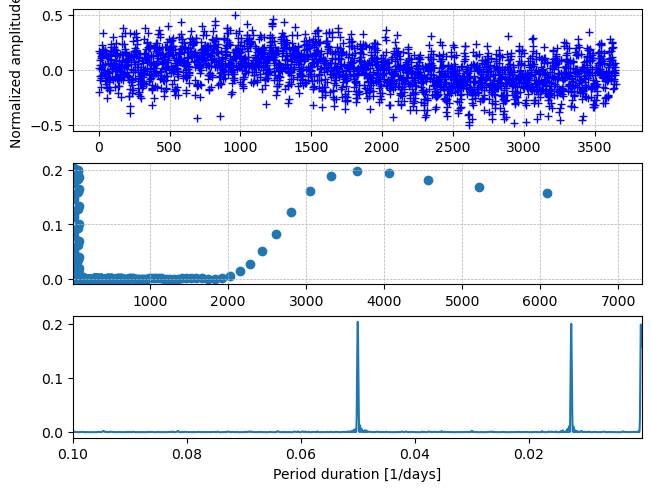

Top 3 Peaks:
          time  frequency  properties
0    20.013886   0.049965    0.203542
1    80.231489   0.012464    0.199679
2  4056.147524   0.000247    0.198522


,time,frequency,properties
0,20.013886,0.049965,0.203542
1,80.231489,0.012464,0.199679
2,4056.147524,0.000247,0.198522


In [8]:
t,y = create_data(trange = 10*365, points = 2500, T = [20,80,10*365], noise = 0.0)   
FourierLombScargle(t,y, plot = True)

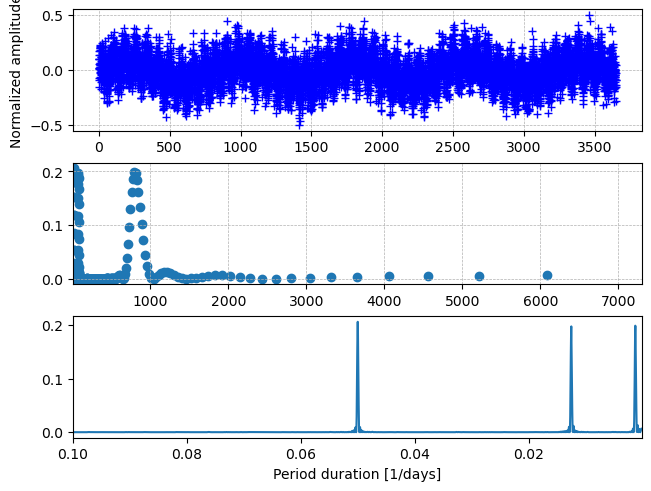

Top 3 Peaks:
         time  frequency  properties
0   20.010666   0.049973    0.205725
1  811.099010   0.001233    0.198477
2   80.218583   0.012466    0.197141


,time,frequency,properties
0,20.010666,0.049973,0.205725
1,811.099010,0.001233,0.198477
2,80.218583,0.012466,0.197141


In [5]:
t,y = create_data(trange = 10*365, points = 10000, T = [20,80,800], noise = 0.0)   
FourierLombScargle(t,y, plot = True)

File does not exist: /Users/amon/Documents/Apps/Python/astro_tool/data/interim/644245485768.pickle
New Path: /Users/amon/Documents/Apps/Python/astro_tool/data/interim/644245485768-light-curves.pickle


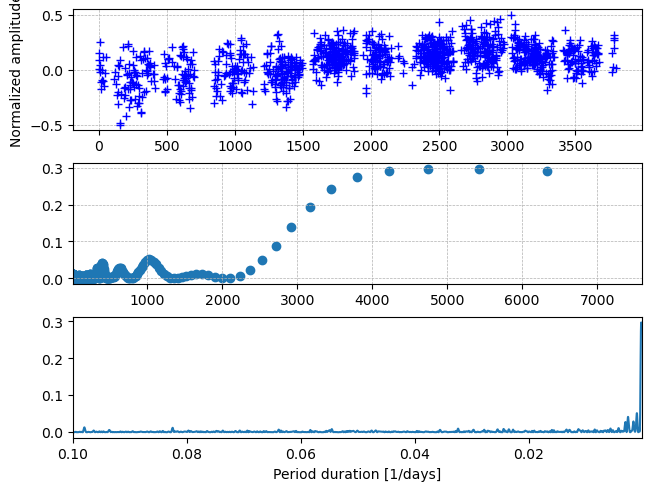

Top 3 Peaks:
          time  frequency  properties
0  5423.369181   0.000184    0.297278
1  1054.544007   0.000948    0.051700


,time,frequency,properties
0,5423.369181,0.000184,0.297278
1,1054.544007,0.000948,0.051700


In [6]:

file = LC.load("644245485768")
data = file.data
t,y = data["JD"], data["Flux"]
FourierLombScargle(t,y, plot = True)

File does not exist: /Users/amon/Documents/Apps/Python/astro_tool/data/interim/103080082019.pickle
New Path: /Users/amon/Documents/Apps/Python/astro_tool/data/interim/103080082019-light-curves.pickle


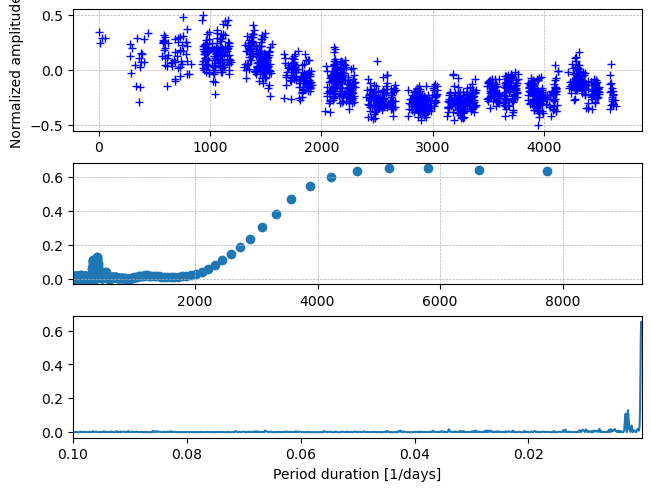

Top 3 Peaks:
          time  frequency  properties
0  6635.867349   0.000151    0.651543
1   400.440271   0.002497    0.129829
2   344.082011   0.002906    0.109143


,time,frequency,properties
0,6635.867349,0.000151,0.651543
1,400.440271,0.002497,0.129829
2,344.082011,0.002906,0.109143


In [7]:
file = LC.load("103080082019")
data = file.data
t,y = data["JD"], data["Flux"]
FourierLombScargle(t,y, plot = True)
